# **🩸Diabetes Prediction**
*This project aims to predict whether a patient is diabetic or not using machine learning models based on medical and lifestyle features.*

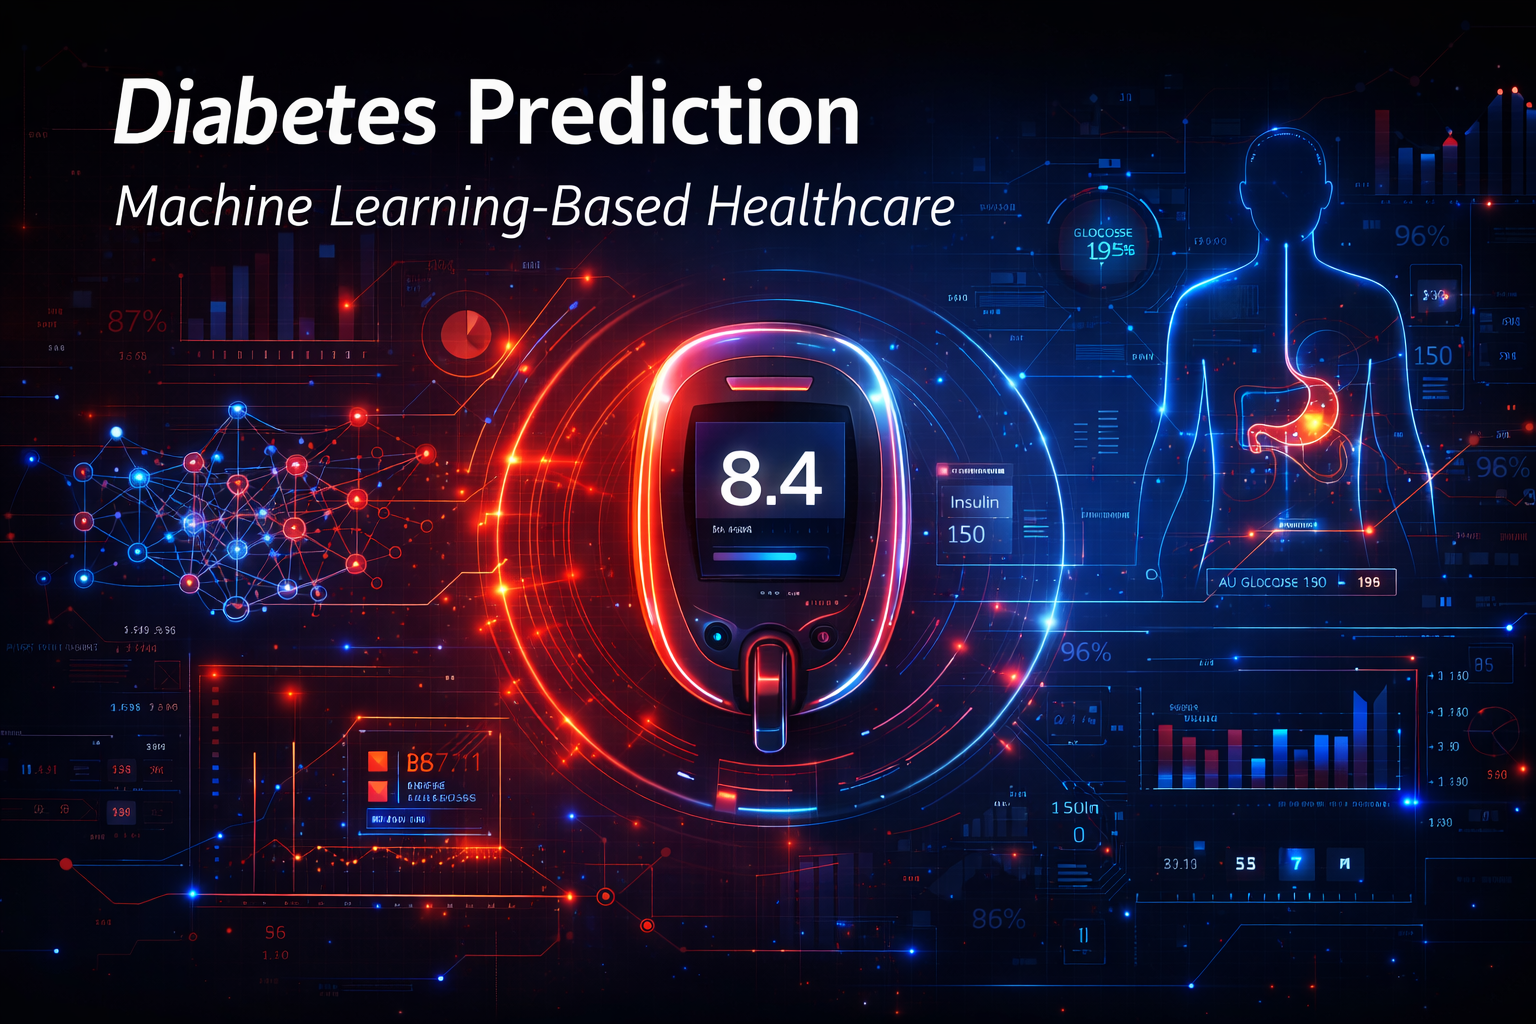

## ***Executive Summary – Diabetes Prediction Notebook***

This notebook presents a structured and efficient machine learning pipeline for predicting the likelihood of diabetes using patient health data. The overall approach emphasizes **simplicity, interpretability, and performance comparison**, ensuring that the model development process remains both practical and aligned with real-world healthcare applications.

The workflow begins with **data exploration and understanding**, where the dataset is analyzed using statistical summaries and visualization techniques. Distribution plots and pairwise relationships help identify patterns in features such as glucose levels, BMI, insulin, and age. These variables play a significant role in distinguishing diabetic and non-diabetic cases, providing initial insights into the dataset.

Feature engineering is applied to enhance model understanding. New categorical features such as BMI levels and insulin conditions are derived to capture more meaningful health interpretations. Additionally, relevant transformations and encoding techniques are used where necessary, ensuring that the dataset is suitable for machine learning algorithms without introducing unnecessary complexity.

The dataset is then split into training and testing sets, followed by training multiple classification models independently. These include *Logistic Regression, K-Nearest Neighbors, Support Vector Machine, Decision Tree, Random Forest, Gradient Boosting,* and *XGBoost*. Each model is evaluated using accuracy metrics and visual comparisons to assess their predictive performance.

The comparative results indicate that **ensemble learning models provide superior performance**. Random Forest and Gradient Boosting demonstrate strong predictive capabilities, achieving higher accuracy and better generalization compared to simpler models. While Decision Tree shows very high training accuracy, it indicates *overfitting*, as the model memorizes training data rather than generalizing effectively.

Visual evaluation using model comparison charts further supports these findings, clearly highlighting performance differences across algorithms. These insights help in selecting the most reliable model for deployment.

The final stage involves saving the best-performing model, ensuring that it can be reused in future applications such as web-based prediction systems or healthcare tools. This makes the notebook not only analytical but also *deployment-ready*.

***In conclusion***, this notebook effectively demonstrates how machine learning can be applied to diabetes prediction using a balanced and well-structured approach. By combining meaningful feature engineering, multiple model evaluation, and clear performance analysis, the project highlights the importance of selecting the right model to achieve accurate and reliable healthcare predictions.


### ***Github_Link***: https://github.com/sUmiT-BhAtT-443/Multiple_Disease_Prediction/tree/main/Notebooks

### ***Import Required Library***

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,mean_absolute_error,accuracy_score,mean_squared_error,r2_score,roc_auc_score,roc_curve,classification_report
from sklearn.preprocessing import scale, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
import warnings
warnings.simplefilter(action='ignore')
sns.set()
plt.style.use("ggplot")
%matplotlib inline

### ***Read Diabetes Dataset***

In [3]:
df= pd.read_csv('../datasets/diabetes.csv')
#TOP 5 ROWS OF DATA
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### ***Understanding Data***

In [4]:
#information regarding data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### ***Columns IN DATASET***

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

### ***Descriptive analysis***


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### **Feature Classification**
---
***Independent Features (Input Variables):***
'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',  
'BMI', 'DiabetesPedigreeFunction', 'Age'

***Dependent Feature (Target Variable):***  
'Outcome'

### ***Check Misiing Values & Dataset shape***

In [7]:
print('MISSING VALUES ARE:-')
print(df.isnull().sum())
print('----------------------------------------------------------')
print('SHAPE OF DATASET:-\n',df.shape)   #rows and column


MISSING VALUES ARE:-
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
----------------------------------------------------------
SHAPE OF DATASET:-
 (768, 9)


## ***Distribution of Target Variable (Outcome)***
In this step, we analyze the distribution of the **target variable (Outcome)** to understand how the data is balanced.

In [8]:
df['Outcome'].value_counts()*100/len(df)

Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64

### ***Age Feature Analysis***

We analyze the **Age** feature using a histogram and also check the **minimum and maximum age** values in the dataset.

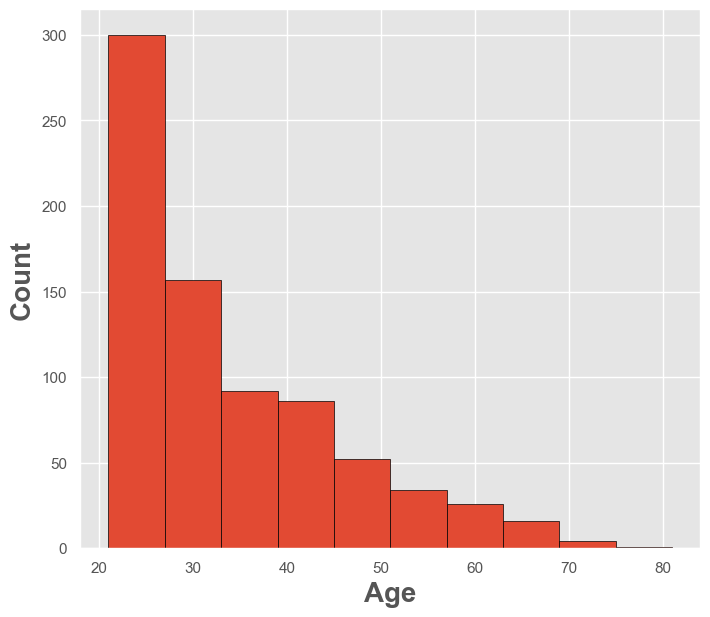

In [9]:
# plot the hist of the age variable
plt.figure(figsize=(8,7))
df['Age'].hist(edgecolor="black")
plt.xlabel('Age', fontsize=20,weight='bold')
plt.ylabel('Count', fontsize=20,weight='bold')
plt.show()

In [10]:
print('THE MAXIMUM AGE IS:',df['Age'].max())
print('THE MINIMUM AGE IS:',df['Age'].min())


THE MAXIMUM AGE IS: 81
THE MINIMUM AGE IS: 21


## ***Feature Distribution Analysis***
We visualize the distribution of important features such as Pregnancies, Glucose, BloodPressure, Insulin, BMI and Age using distribution plots.

### *These plots help understand:*
- data distribution
- skewness
- potential outliers

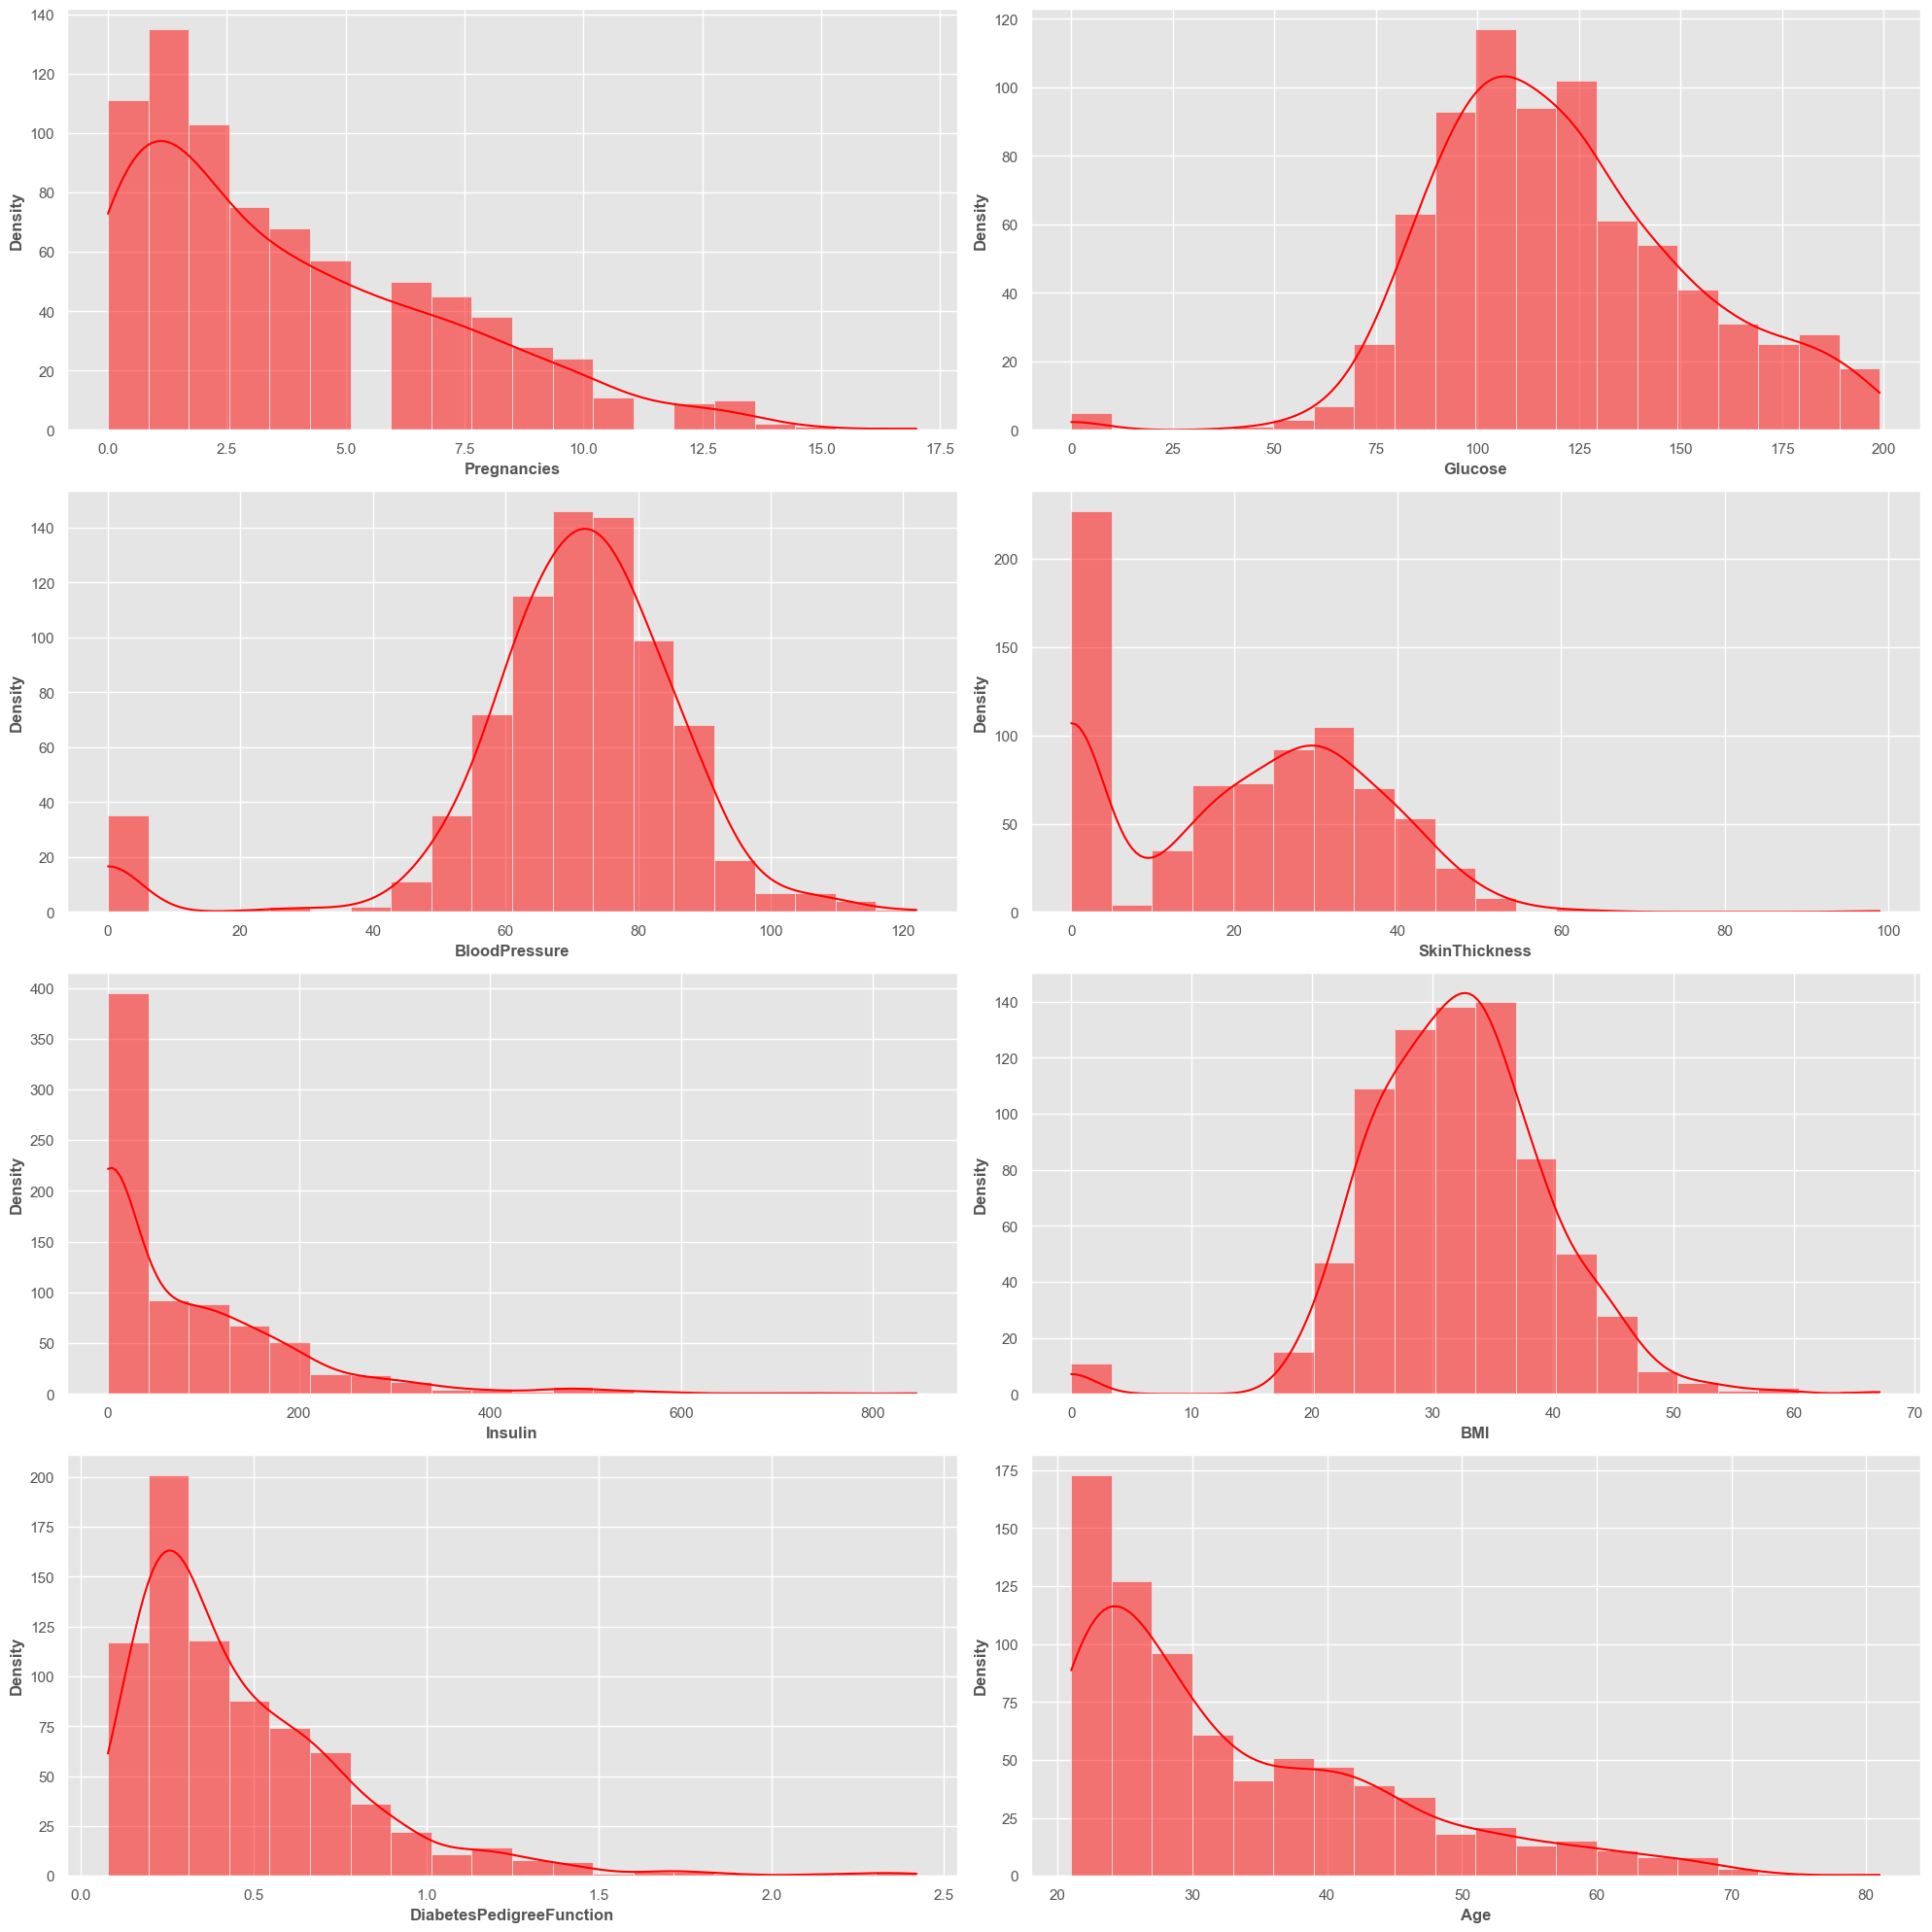

In [11]:
fig, ax = plt.subplots(4, 2, figsize=(20,20))

sns.histplot(df.Pregnancies, bins=20, kde=True, ax=ax[0,0], color='red')
ax[0,0].set_xlabel('Pregnancies', fontweight='bold')
ax[0,0].set_ylabel('Density', fontweight='bold')

sns.histplot(df.Glucose, bins=20, kde=True, ax=ax[0,1], color='red')
ax[0,1].set_xlabel('Glucose', fontweight='bold')
ax[0,1].set_ylabel('Density', fontweight='bold')

sns.histplot(df.BloodPressure, bins=20, kde=True, ax=ax[1,0], color='red')
ax[1,0].set_xlabel('BloodPressure', fontweight='bold')
ax[1,0].set_ylabel('Density', fontweight='bold')

sns.histplot(df.SkinThickness, bins=20, kde=True, ax=ax[1,1], color='red')
ax[1,1].set_xlabel('SkinThickness', fontweight='bold')
ax[1,1].set_ylabel('Density', fontweight='bold')

sns.histplot(df.Insulin, bins=20, kde=True, ax=ax[2,0], color='red')
ax[2,0].set_xlabel('Insulin', fontweight='bold')
ax[2,0].set_ylabel('Density', fontweight='bold')

sns.histplot(df.BMI, bins=20, kde=True, ax=ax[2,1], color='red')
ax[2,1].set_xlabel('BMI', fontweight='bold')
ax[2,1].set_ylabel('Density', fontweight='bold')

sns.histplot(df.DiabetesPedigreeFunction, bins=20, kde=True, ax=ax[3,0], color='red')
ax[3,0].set_xlabel('DiabetesPedigreeFunction', fontweight='bold')
ax[3,0].set_ylabel('Density', fontweight='bold')

sns.histplot(df.Age, bins=20, kde=True, ax=ax[3,1], color='red')
ax[3,1].set_xlabel('Age', fontweight='bold')
ax[3,1].set_ylabel('Density', fontweight='bold')

plt.tight_layout()
plt.show()

### **Feature Distribution Insights**

**Insight:**

- Most features like **Glucose, BMI, BloodPressure** show near normal distribution.  
- Features like **Insulin and SkinThickness** are highly skewed due to many zero values (missing data).  
- **Pregnancies, Age, DiabetesPedigreeFunction** are right-skewed.  
- Presence of **outliers and missing values** may affect model performance.

**Conclusion:**  
Data preprocessing (handling zeros & skewness) is required before model training.

### ***Pregnancies Analysis(Mean+Max)***

In [12]:
df.groupby("Outcome").agg({'Pregnancies':'mean'})

,Pregnancies
Outcome,
0,3.298000
1,4.865672


In [13]:
df.groupby("Outcome").agg({'Pregnancies':'max'})

,Pregnancies
Outcome,
0,13
1,17


### ***Glucose Analysis(Mean+Max)***

In [14]:
df.groupby("Outcome").agg({'Glucose':'mean'})

,Glucose
Outcome,
0,109.980000
1,141.257463


In [15]:
df.groupby("Outcome").agg({'Glucose':'max'})

,Glucose
Outcome,
0,197
1,199


### ***Target Variable Visualization***
We visualize the distribution of diabetic and non-diabetic patients using pie chart and countplot.

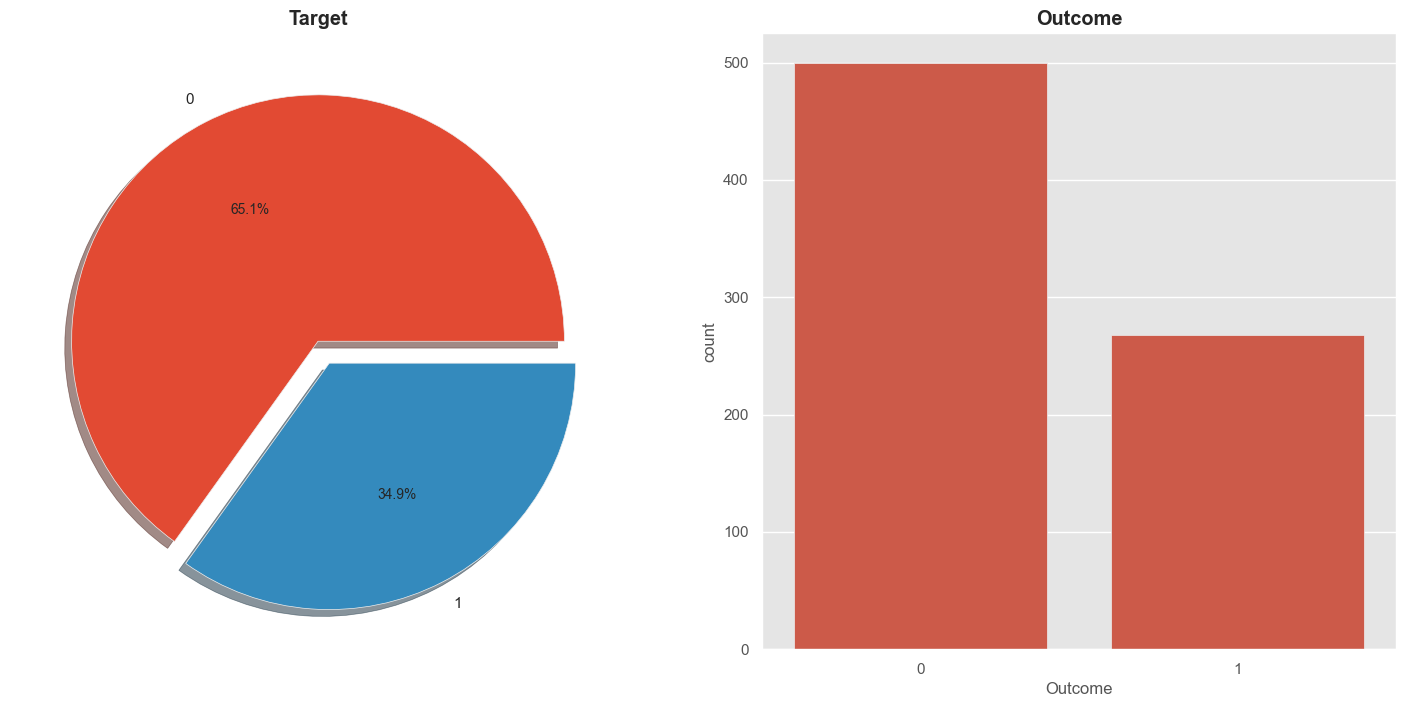

In [16]:
f,ax = plt.subplots(1,2, figsize=(18,8))

df['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct="%1.1f%%", ax=ax[0], shadow=True)
ax[0].set_title('Target',weight='bold')
ax[0].set_ylabel('')

sns.countplot(x='Outcome', data=df, ax=ax[1])
ax[1].set_title('Outcome',weight='bold')

plt.show()

**Insight:**
- Dataset is slightly imbalanced (~65% non-diabetic, ~35% diabetic)
- Model training may require careful evaluation due to imbalance

### ***Feature Correlation Analysis:*** We analyze relationships between features using correlation matrix.

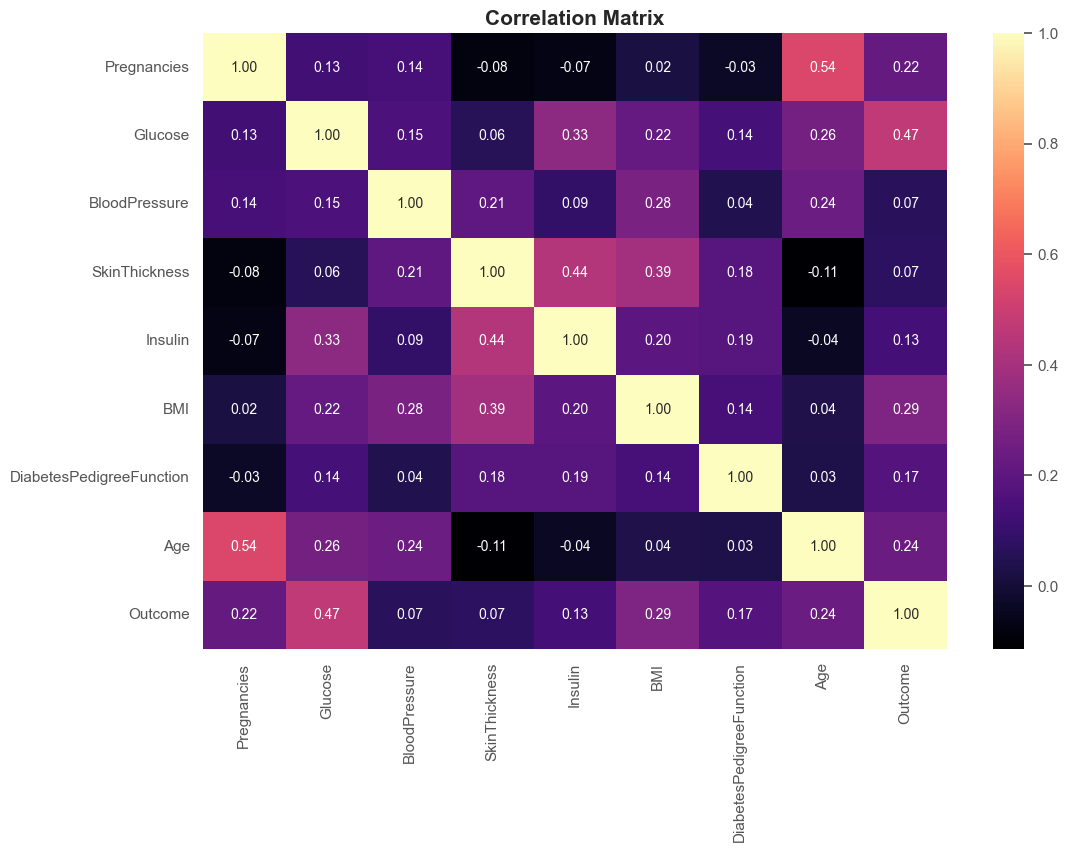

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='magma', fmt=".2f")
plt.title("Correlation Matrix", fontsize=15,weight='bold')
plt.show()

## **Insight:**
- **Glucose** has strongest correlation with Outcome
- **BMI & Age** also moderately related
- Other features show weak correlation

### ***Handling Missing Values:***
- Zero values are unrealistic for some features, so we replace them with NaN.

In [18]:
#replace  with Nan
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols] = df[cols].replace(0, np.nan)
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### ***Missing Value Imputation:*** We fill missing values using median based on Outcome groups.

In [19]:
def median_target(col):
    return df.groupby("Outcome")[col].median()

for col in cols:
    df.loc[(df['Outcome']==0) & (df[col].isnull()), col] = median_target(col)[0]
    df.loc[(df['Outcome']==1) & (df[col].isnull()), col] = median_target(col)[1]

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## ***📊 Missing Values Analysis***
This chart shows the count of non-missing values in each feature.

<Axes: >

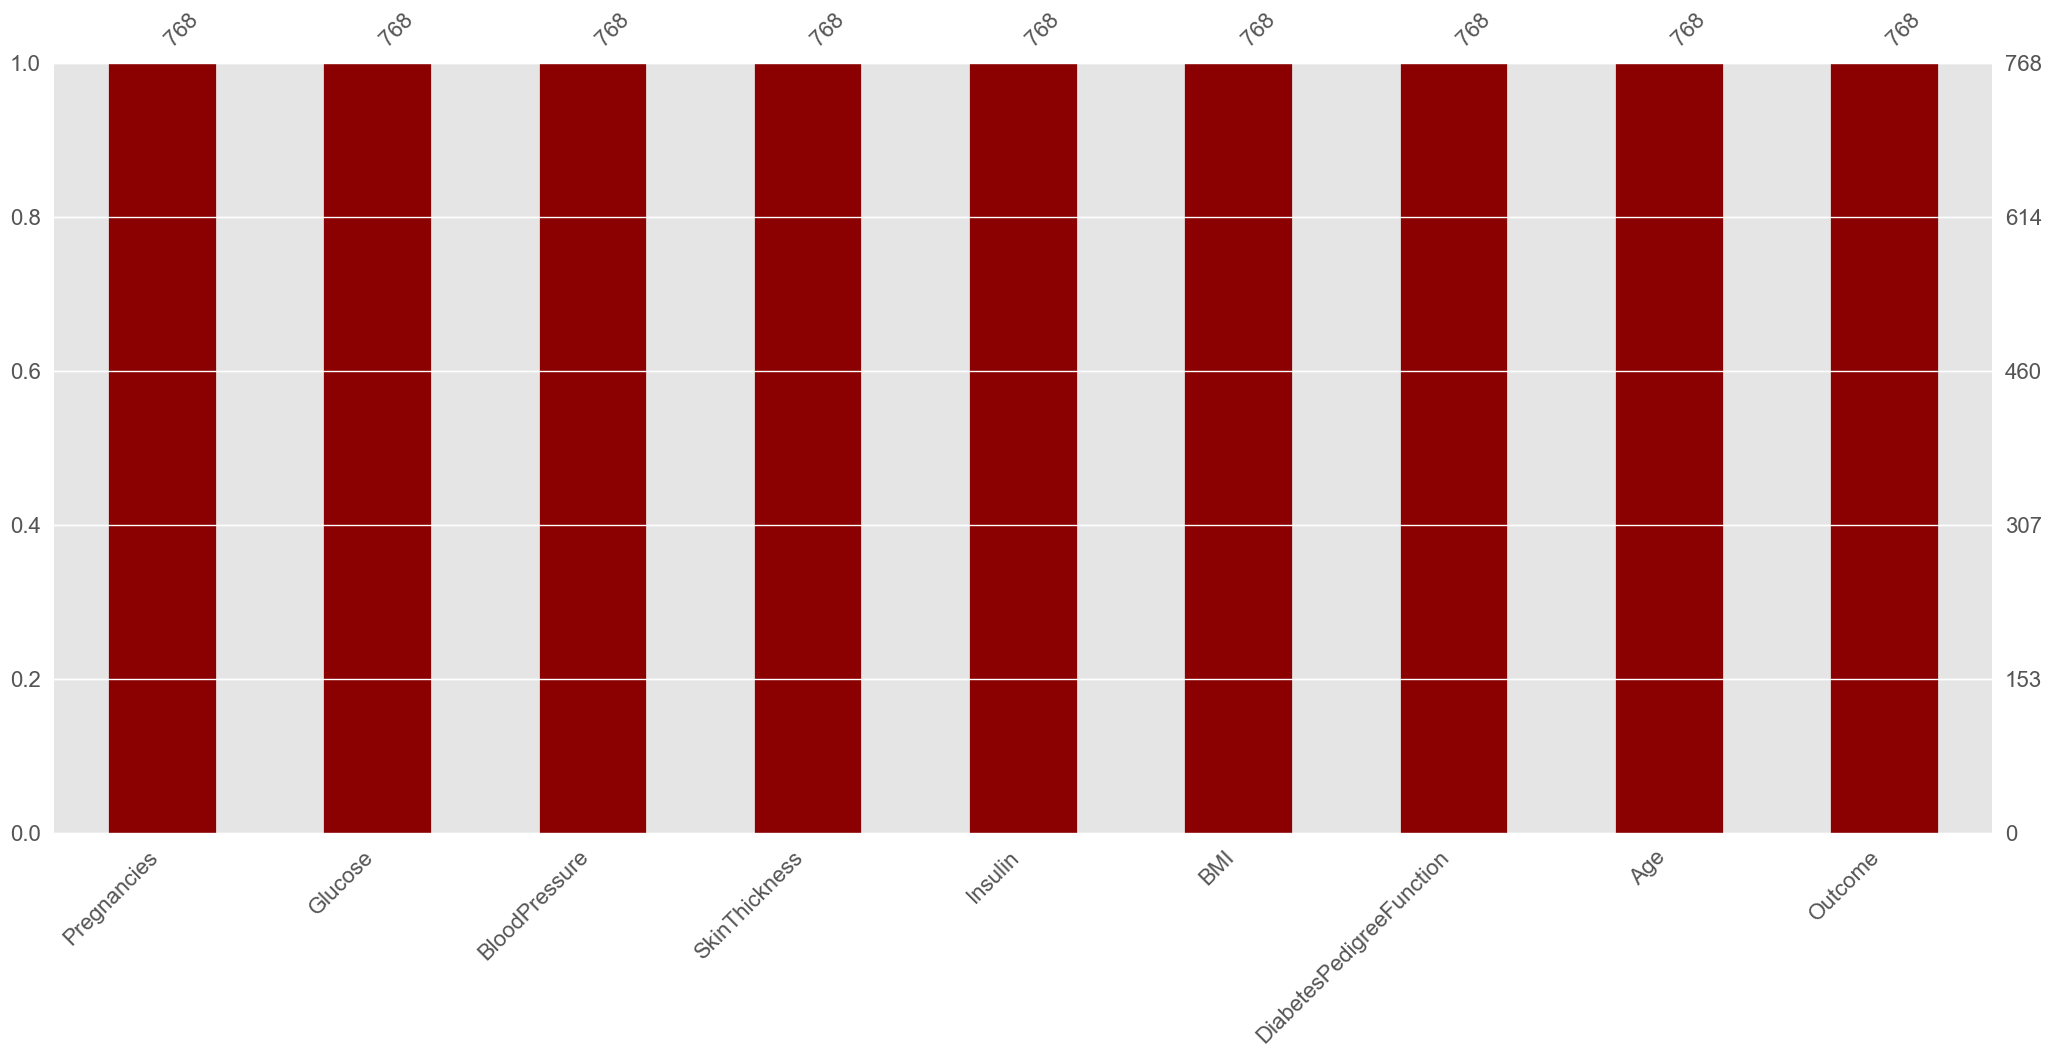

In [20]:
import missingno as msno
msno.bar(df, color="darkred")

### ***📌 Insight***
- All features have complete data (no missing values present)
- Dataset is clean and ready for model training

## ***📊 Pairwise Feature Relationship Analysis (Pairplot)***

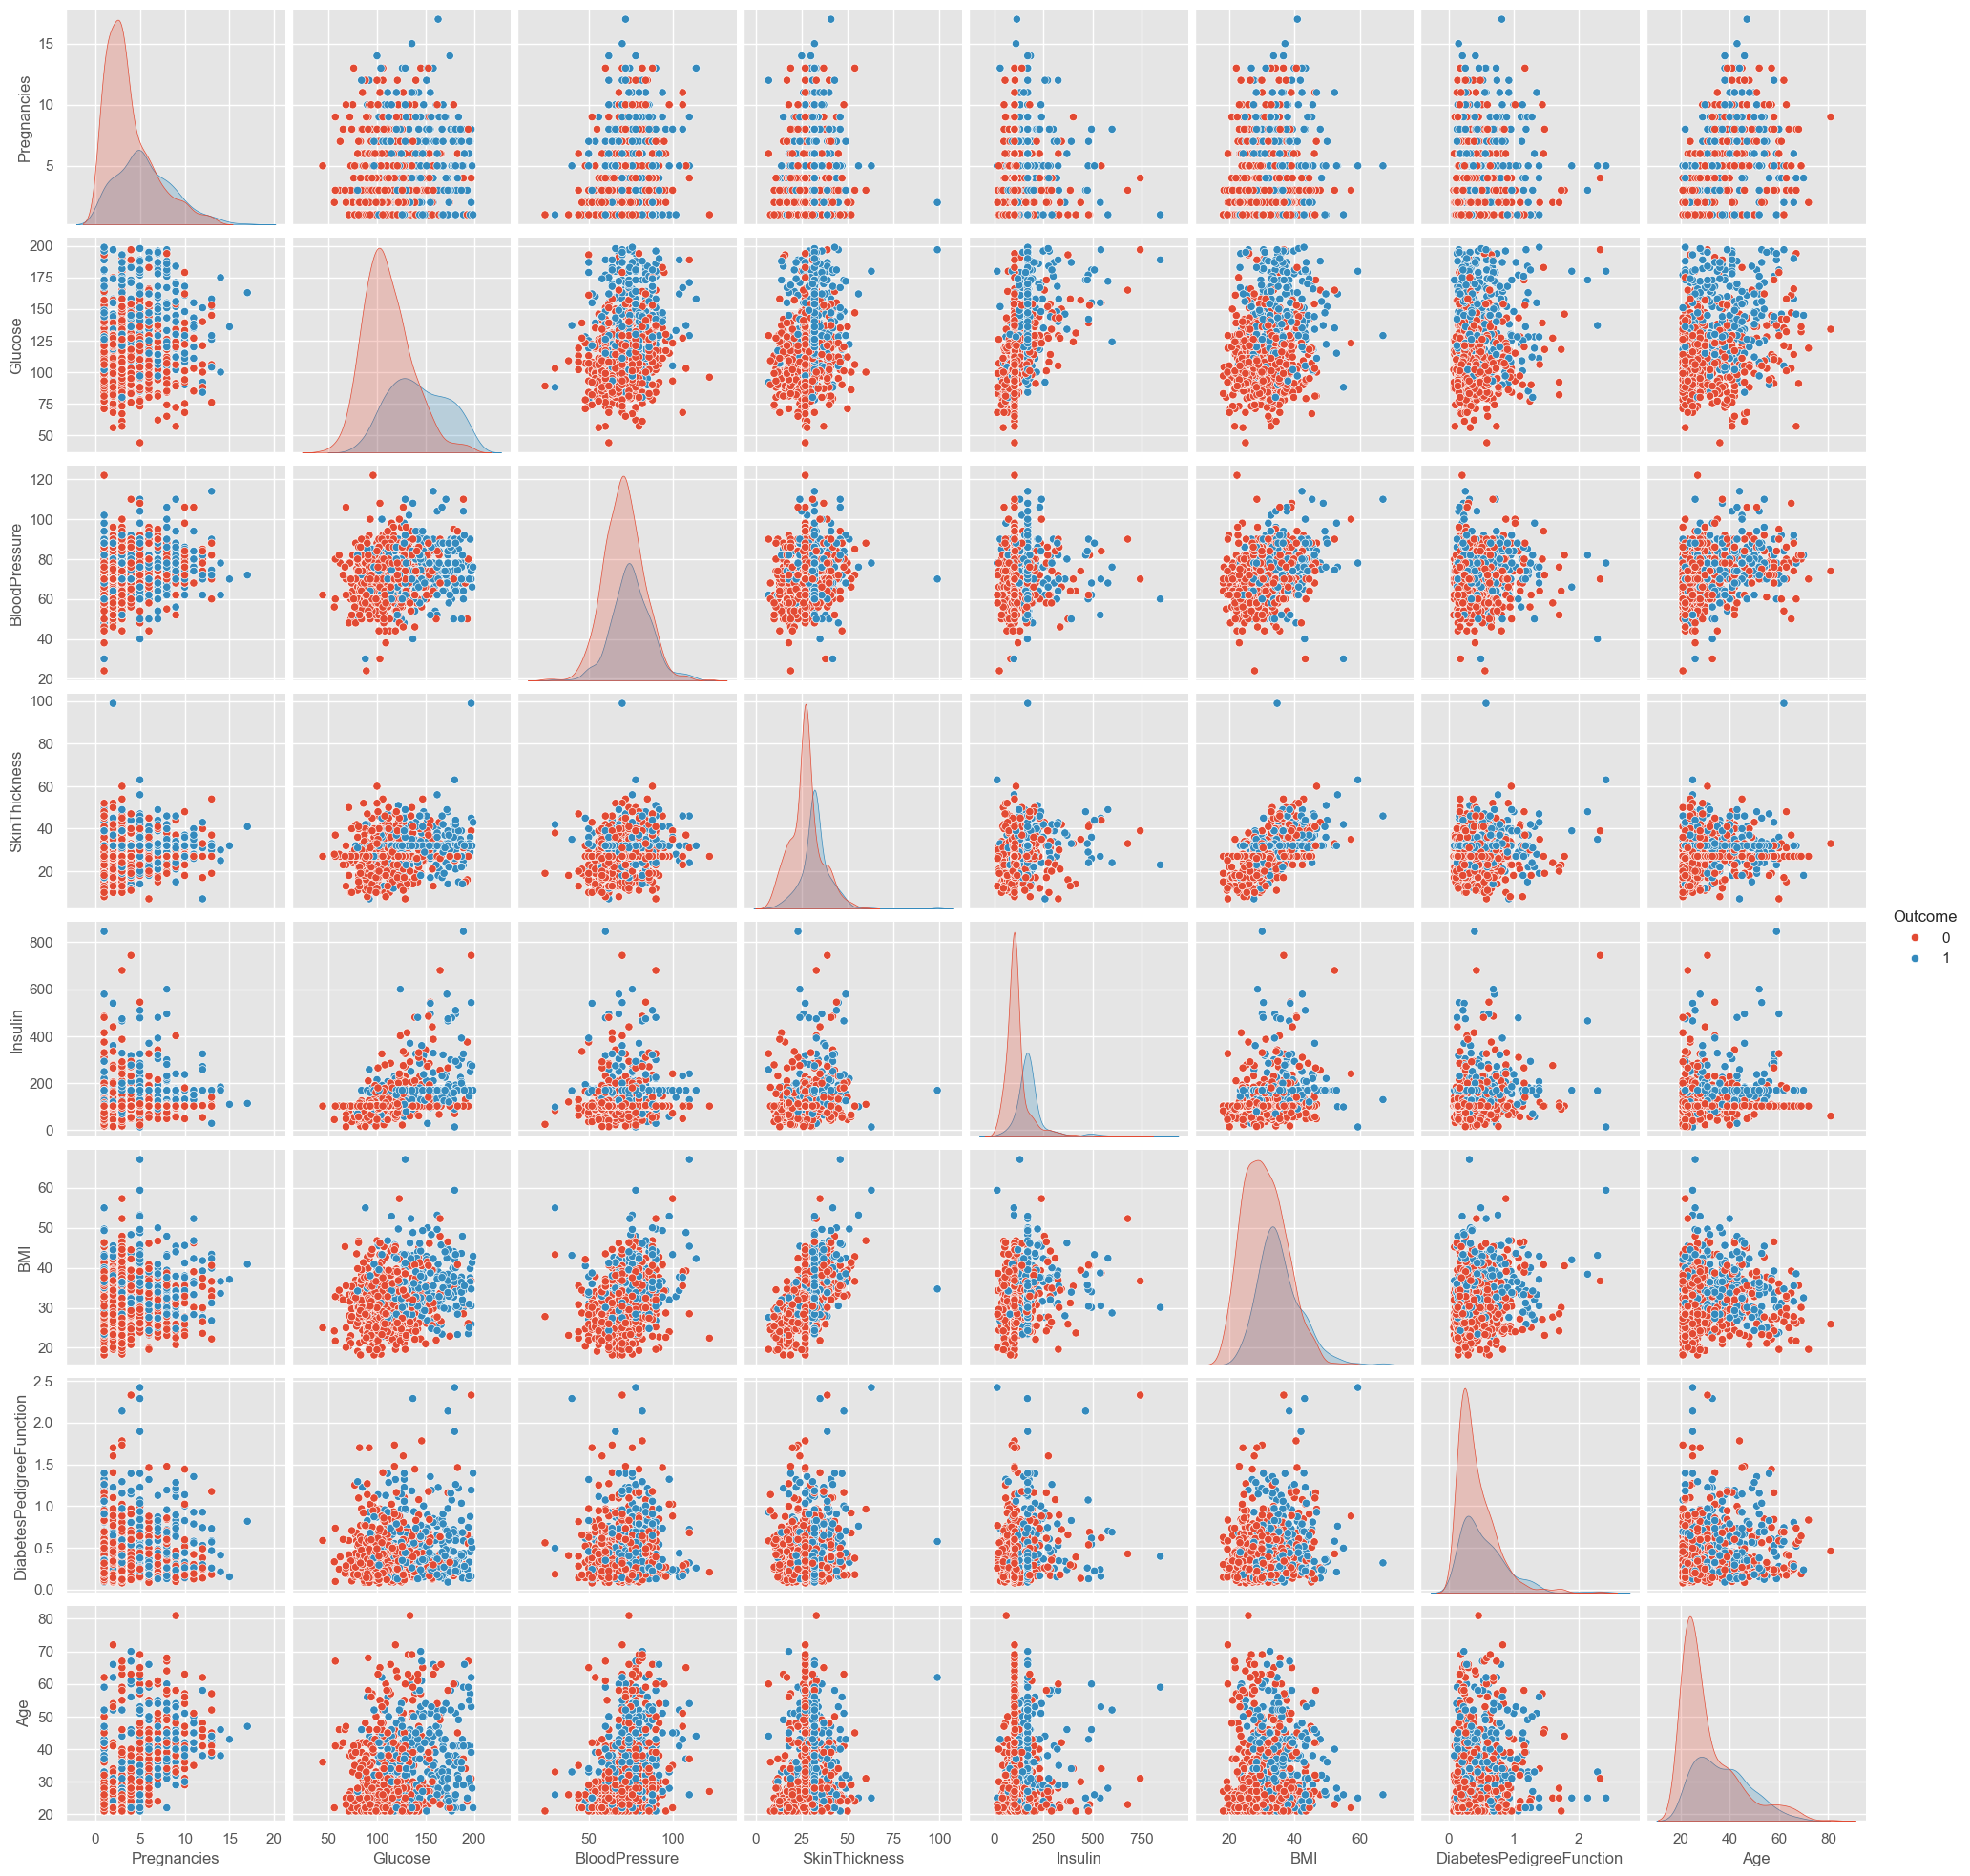

In [21]:
p = sns.pairplot(df, hue="Outcome")

### ***Outlier Detection:*** We detect outliers using IQR method.

In [22]:
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    df[col] = np.where(df[col] > upper, upper, df[col])
    df[col] = np.where(df[col] < lower, lower, df[col])

for col in cols:
    cap_outliers(col)

### ***Feature Scaling:***
We scale features using StandardScaler for better model performance.

In [23]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### ***Model Training & Evaluation***
We train multiple ML models and compare their performance.

## ***🤖 Logistic Regression***

In [24]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8246753246753247
[[85 14]
 [13 42]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.86        99
           1       0.75      0.76      0.76        55

    accuracy                           0.82       154
   macro avg       0.81      0.81      0.81       154
weighted avg       0.83      0.82      0.83       154



## ***🤖 KNN***

In [25]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.8701298701298701
[[88 11]
 [ 9 46]]
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        99
           1       0.81      0.84      0.82        55

    accuracy                           0.87       154
   macro avg       0.86      0.86      0.86       154
weighted avg       0.87      0.87      0.87       154



## ***🤖 SVM (Best Model)***

In [26]:
svc = SVC(C=10, gamma=0.01, probability=True)
svc.fit(X_train, y_train)

y_pred_svm = svc.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8896103896103896
[[89 10]
 [ 7 48]]
              precision    recall  f1-score   support

           0       0.93      0.90      0.91        99
           1       0.83      0.87      0.85        55

    accuracy                           0.89       154
   macro avg       0.88      0.89      0.88       154
weighted avg       0.89      0.89      0.89       154



## ***🤖 Random Forest***

In [27]:
rf = RandomForestClassifier(n_estimators=150, max_depth=10)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8766233766233766
[[87 12]
 [ 7 48]]
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        99
           1       0.80      0.87      0.83        55

    accuracy                           0.88       154
   macro avg       0.86      0.88      0.87       154
weighted avg       0.88      0.88      0.88       154



## ***🤖 Gradient Boosting***

In [28]:
gb = GradientBoostingClassifier(n_estimators=150)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.8766233766233766
[[88 11]
 [ 8 47]]
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        99
           1       0.81      0.85      0.83        55

    accuracy                           0.88       154
   macro avg       0.86      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



## ***📊 Model Comparison***

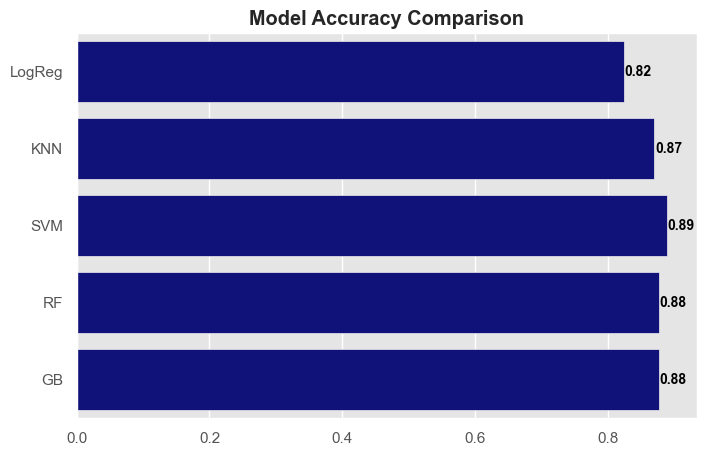

In [29]:
model_names = ["LogReg", "KNN", "SVM", "RF", "GB"]
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb)
]

plt.figure(figsize=(8,5))
ax = sns.barplot(x=accuracies, y=model_names, color='darkblue')

#for show accuracy
for i, v in enumerate(accuracies):
    ax.text(v + 0.001, i, f"{v:.2f}", color='black', va='center', fontweight='bold')

plt.title("Model Accuracy Comparison", weight='bold')
plt.show()

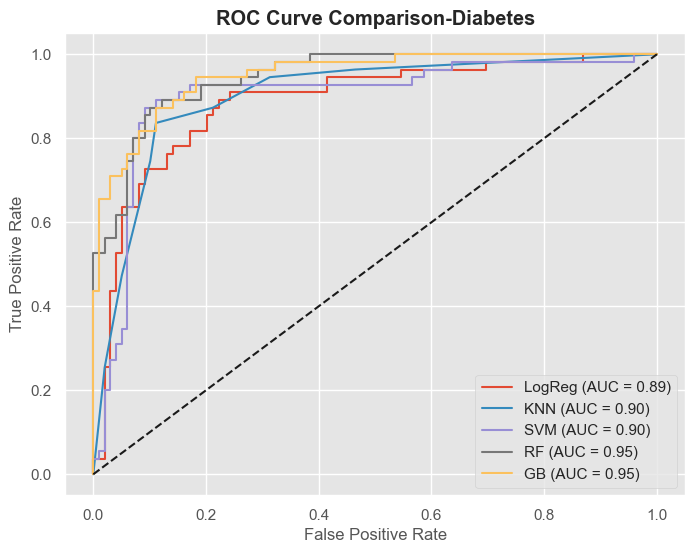

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_svm = svc.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

# AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f'LogReg (AUC = {auc_lr:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'RF (AUC = {auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'GB (AUC = {auc_gb:.2f})')

# Random line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison-Diabetes', weight='bold')
plt.legend()
plt.show()

## ***💾 Saving Best Model***

In [ ]:
import pickle
pickle.dump(svc, open("../models/diabetes_model.pkl", "wb"))

## ***🚀 Final Conclusion – Diabetes Prediction Model***

In this project, a machine learning model was developed to predict diabetes based on medical attributes. A structured approach was followed, starting from data understanding to model evaluation, ensuring reliable and accurate predictions.

During the analysis, it was observed that certain features had a stronger influence on the prediction outcome, indicating clear patterns in the dataset. Proper data preprocessing played a crucial role in improving model performance. Handling missing values, treating outliers, and applying feature scaling helped in stabilizing the data and reducing noise.

Multiple classification models were trained and evaluated, including Logistic Regression, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Random Forest, and Gradient Boosting. Each model was assessed using accuracy, confusion matrix, and classification metrics to compare their effectiveness.

Among all the models, Support Vector Machine (SVM) consistently performed the best. It achieved the highest accuracy while maintaining a strong balance between precision and recall. This indicates that the dataset has well-defined class boundaries, making SVM a suitable choice for this problem.

Ensemble models like Random Forest and Gradient Boosting also delivered strong performance, showing their ability to handle complex relationships in the data. However, simpler models like Logistic Regression and KNN, although effective, showed slightly lower performance in comparison.

Overall, the results demonstrate that proper preprocessing combined with the right model selection significantly improves prediction accuracy. The final model is capable of making reliable predictions and can be further used for deployment or extended to other disease prediction tasks.

In conclusion, this project successfully builds a high-performing diabetes prediction model, highlighting the importance of data quality, model comparison, and evaluation in machine learning workflows.
